In [1]:
suppressMessages({library(rwwa); library(quantreg); library(mev)})
png_res <- 240

# Trends in monthly mean precip

In [ ]:
ds_nm <- "chirps"
pr <- read.csv(paste0("pr-daily_bas_",ds_nm,".csv"))

gmst <- read.table("gmst.dat", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2026]


df <- merge(gmst, aggregate(pr$pr, by = list("year" = as.integer(substr(pr$time,1,4)), "month" = as.integer(substr(pr$time,6,7))), "mean"))
df$month <- as.factor(df$month)
df$logpr <- log(df$x)

In [3]:
png(paste0("fig/monthly-trends_",ds_nm,".png"), h = png_res * 2, w = png_res * 6); {
    prep_window(c(2,6), oma = c(0,0,2,0))

    for (i in 1:12) {
        pr_m <- df[df$month == i,]
        plot_trend(fit_ns("norm", "fixeddisp", pr_m, covnm = "gmst", varnm = "x"), main = i, legend_pos = NA, ylim = c(0,20), xlim = c(1960,2026))
    }
    mtext(ds_nm, outer = T, side = 3, font = 2)
}; dev.off()


agg_record_915699364 
                   2

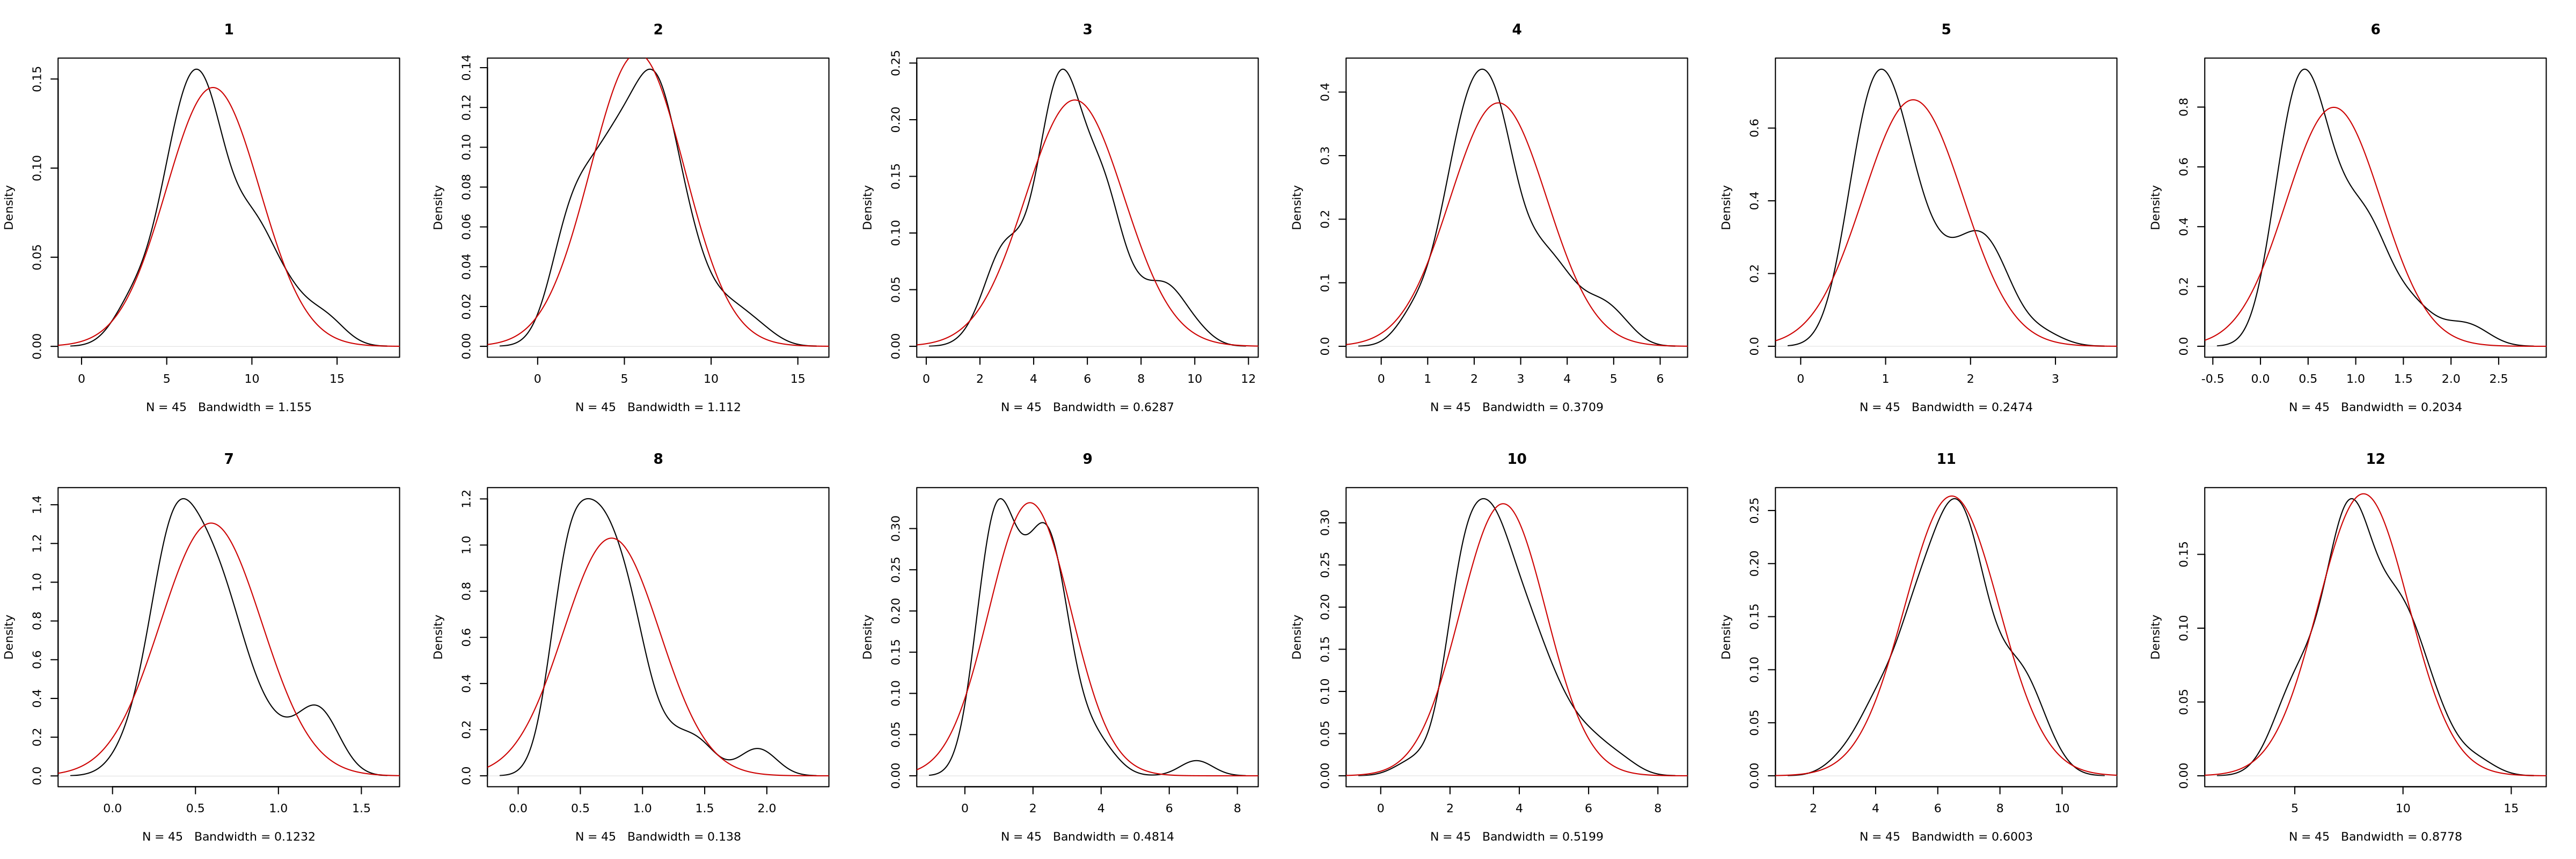

In [4]:
prep_window(c(2,6))

for (i in 1:12) {
    pr_m <- (df$x[df$month == i])
    plot(density(pr_m), main = i)
    lines(x <- seq(-5,25,0.01), dnorm(x, mean(pr_m), sd(pr_m)), col = "red3")
}

In [5]:
mdl <- lm(x ~ gmst * month, df)
lmdl <- lm(logpr ~ gmst * month, df)

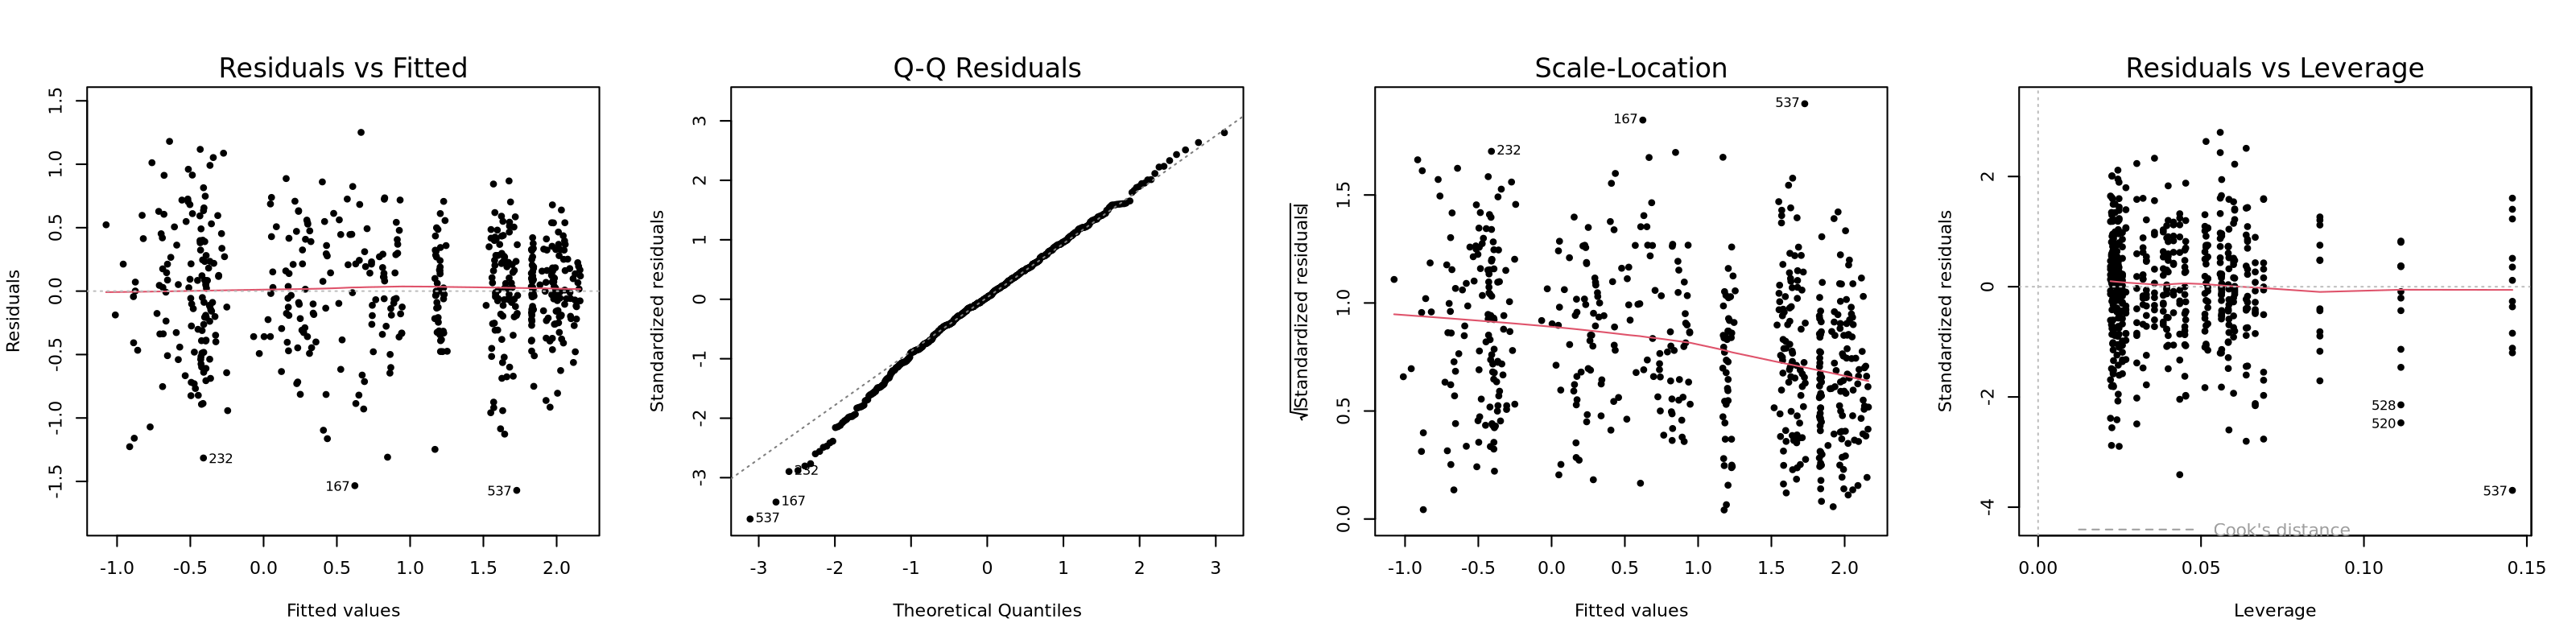

In [6]:
prep_window(c(1,4))
plot(lmdl)

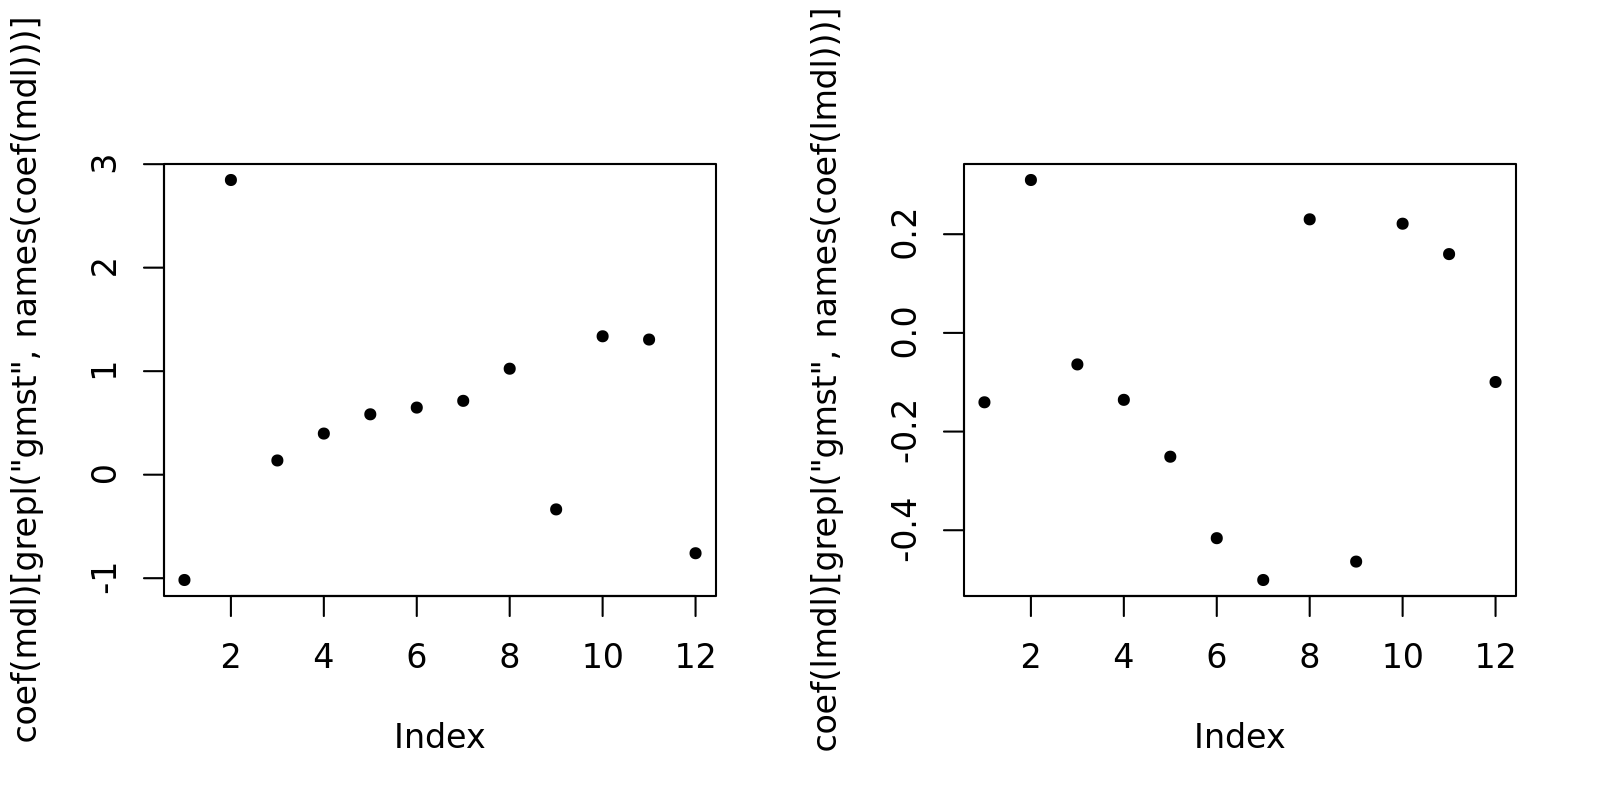

In [7]:
prep_window(c(1,2))

plot(coef(mdl)[grepl("gmst", names(coef(mdl)))])
plot(coef(lmdl)[grepl("gmst", names(coef(lmdl)))])

# Quantile regression

In [ ]:
qq <- c(0.005,0.01,0.02,0.03,0.05,seq(0.1,0.9,0.1),0.95,0.975,0.99,0.995)
qr_tmax <- rq(x ~ gmst, data = df, tau = qq)
qpred_tmax <- fitted(qr_tmax) #  get fitted quantiles

In [12]:
# qr_summ <- summary(qr_tmax, se = "boot") # get standard errors of coeffs by bootstrapping (can be v slow so don't want to repeat)
# coeffs <- sapply(qr_summ, function(res) res$coefficients["gmst",], simplify = T)
# write.csv(setNames(data.frame(coeffs), qq), paste0("qcoeffs-boot_",ds_nm,".csv"))
coeffs <- read.csv(paste0("qcoeffs-boot_",ds_nm,".csv"), row.names = "X")

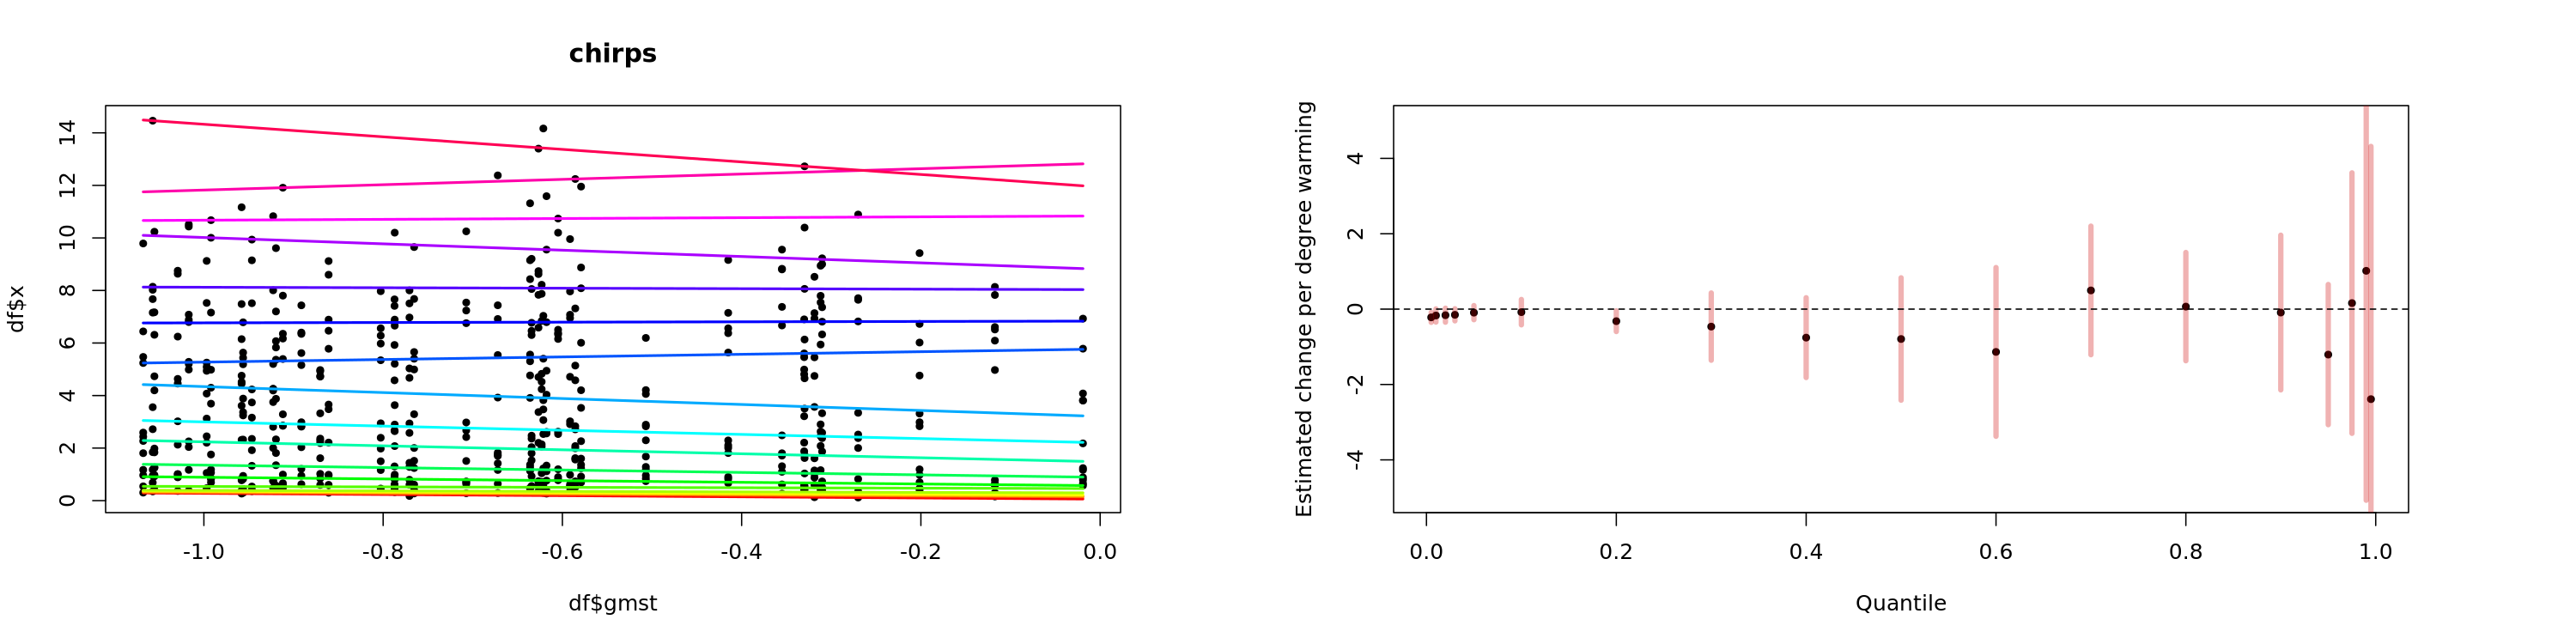

In [22]:
prep_window(c(1,2), mar = c(5.1, 4.1, 4.1, 6.5), res = 150, h = 5, w = 10)
plot(df$gmst, df$x, main = paste0(ds_nm))
matplot(df$gmst, qpred_tmax, add = T, type = "l", lty = 1, lwd = 2, col = rainbow(length(qq)))
# legend("right", inset = c(-0.22, 0), legend = qq, lty = 1, col = rainbow(length(qq)), bty = "n")

plot(as.numeric(gsub("X","",colnames(coeffs))), coeffs["Value",], pch = 20, xlab = "Quantile", ylab = "Estimated change per degree warming", ylim = c(-5,5))
segments(x0 = as.numeric(gsub("X","",colnames(coeffs))), 
         y0 = unlist(coeffs["Value",] - 1.96*coeffs["Std. Error",]), 
         y1 = unlist(coeffs["Value",] + 1.96*coeffs["Std. Error",]), col = adjustcolor("red3", 0.3), lwd = 4)
abline(h = 0, col = "black", lty = 2)

# All monthly trends

In [62]:
fl <- list.files(pattern = "pr-monthly.+.csv")

gmst <- read.table("gmst.dat", col.names = c("year", "gmst"))
gmst$gmst <- gmst$gmst - gmst$gmst[gmst$year == 2026]

cov_f <- gmst[gmst$year == 2026,,drop = F]
cov_cf <- cov_f - 1.3

## Fixed-disp GEV

In [74]:
for (fnm in fl) {
    ds_nm <- gsub(".+_|.csv","",fnm)
    new_fnm <- paste0("res/dI-rel_per-month_",ds_nm,".csv")
    if (file.exists(new_fnm)) next
    
    pr <- read.csv(fnm, col.names = c("time", "pr"))
    pr$year <- as.integer(substr(pr$time,1,4))
    pr$month <- as.integer(substr(pr$time,6,7))

    df <- merge(gmst, pr)

    # bootstrap the change in intensity (small sample only)
    dI <- sapply(1:12, function(m) {
        mdl <- fit_ns("norm", "fixeddisp", df[df$month == m,], covnm = "gmst", varnm = "pr", lower = F)
        boot_ci(mdl, cov_f, cov_cf, nsamp = 250)["dI_rel",]
    })
    write.csv(setNames(data.frame(dI), 1:12), new_fnm)
}

In [2]:
# plot parameters
dI_rel <- abind::abind(sapply(list.files("res", pattern = "dI-rel_per-month", full.names = T), read.csv, row.names = "X", simplify = F), along = 0)

In [7]:
dimnames(dI_rel)

[[1]]
[1] "res/dI-rel_per-month_bzgd.csv"   "res/dI-rel_per-month_chirps.csv"
[3] "res/dI-rel_per-month_cruts.csv"  "res/dI-rel_per-month_gpcc.csv"  
[5] "res/dI-rel_per-month_mswep.csv" 

[[2]]
[1] "est"   "2.5%"  "97.5%"

[[3]]
 [1] "X1"  "X2"  "X3"  "X4"  "X5"  "X6"  "X7"  "X8"  "X9"  "X10" "X11" "X12"

In [26]:
png_res <- 360
png("alpha-monthly.png", h = png_res, w = png_res * 2); {
    prep_window(res = 140, w = 9, h = 5, mar = c(2.6,4.1,1,1))

    plot(0, type = "n", xlim = c(0.75,12.25), ylim = range(pretty(dI_rel)), ylab = "% change in monthly precip", xlab = "", xaxt = "n")
    
    for (i in 1:5) {
        points((1:12) - 0.375 + i/8, dI_rel[i,1,], pch = 20)
        segments(x0 = (1:12) - 0.375 + i/8, y0 = dI_rel[i,2,], y1 = dI_rel[i,3,], lwd = 5, col = adjustcolor(i, 0.5))
    }
    axis(1, at = 1:12, labels = substr(month.name,1,3))
    
    abline(h = 0, lty = 2)
    
    legend("topright", legen = gsub(".+_|.csv","",rownames(dI_rel)), col = adjustcolor(1:5, 0.5), lty = 1, lwd = 5, title = "Dataset")
}; dev.off()

agg_record_1859048669 
                    2

## MV linear model

In [44]:
for (fnm in fl[1]) {
    ds_nm <- gsub(".+_|.csv","",fnm)
    pr <- read.csv(fnm, col.names = c("time", "pr"))
    pr$year <- as.integer(substr(pr$time,1,4))
    pr$month <- as.factor(substr(pr$time,6,7))

    df <- merge(gmst, pr)

    mdl <- lm(pr ~ gmst * month, df)
    coef <- summary(mdl)$coefficients

    
}

In [55]:
coef[grepl("gmst", rownames(coef)),]

,Estimate,Std. Error,t value,Pr(>|t|)
gmst,-20.384954,20.06867,-1.01575982,0.3100780
gmst:month02,31.749419,28.38139,1.11867025,0.2636463
gmst:month03,34.409722,28.38139,1.21240430,0.2257472
gmst:month04,21.970402,28.96837,0.75842719,0.4484384
gmst:month05,22.488166,28.96837,0.77630059,0.4378213
gmst:month06,18.082682,28.96837,0.62422151,0.5326758
gmst:month07,7.637372,28.96837,0.26364516,0.7921273
gmst:month08,21.654207,28.96837,0.74751199,0.4549936
gmst:month09,14.738402,28.96837,0.50877559,0.6110622
gmst:month10,1.596445,28.96837,0.05510991,0.9560659


In [ ]:
ds_nm <- "chirps"
pr <- read.csv(paste0("pr-daily_bas_",ds_nm,".csv"))




df <- merge(gmst, aggregate(pr$pr, by = list("year" = as.integer(substr(pr$time,1,4)), "month" = as.integer(substr(pr$time,6,7))), "mean"))